In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import sys
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
sys.path.append('../../../src')
from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, SamplingEnum, FilterEnum, ErrorEnum, NoiseTypeEnum
from scipy.optimize import minimize
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from noise_optimizers import EKF_NoiseOptimizer
from numpy.linalg import norm

%matplotlib inline
np.random.seed(777)

## Load data

In [2]:
kitti_root_dir = '../../../data'
vo_root_dir = '../../../vo_estimates'
noise_vector_dir = '../../../exports/_noise_optimizations/noise_vectors'
kitti_date = '2011_09_30'
kitti_drive = '0033'
data = DataLoader(sequence_nr=kitti_drive, 
                kitti_root_dir=kitti_root_dir, 
                vo_root_dir=vo_root_dir,
                noise_vector_dir=noise_vector_dir,
                vo_dropout_ratio=0.0, 
                gps_dropout_ratio=0.0,
                upsampling_factor=10,
                downsampling_ratio=0.8,
                visualize_data=False)

Data sampling is set to normal mode.


In [3]:
error_df_export_path = '../../../exports/_noise_optimizations/errors/ekf'
noise_vector_export_path = '../../../exports/_noise_optimizations/noise_vectors/ekf'

In [4]:
ekf_optimizer = EKF_NoiseOptimizer(data=data, 
                                   error_df_export_path=error_df_export_path, 
                                   noise_vector_export_path=noise_vector_export_path)

In [5]:
ekf_optimizer.run()

Finding optimal noise vector
For setup 1
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 93612.61894253037
             x: [ 9.659e-01  9.686e-01  1.128e+00  1.291e+00  9.235e-01
                  1.259e+00  1.104e+00  1.182e-01  1.082e+00  9.126e-01]
           nit: 353
          nfev: 746
 final_simplex: (array([[ 9.659e-01,  9.686e-01, ...,  1.082e+00,
                         9.126e-01],
                       [ 9.659e-01,  9.686e-01, ...,  1.082e+00,
                         9.126e-01],
                       ...,
                       [ 9.659e-01,  9.686e-01, ...,  1.082e+00,
                         9.126e-01],
                       [ 9.659e-01,  9.686e-01, ...,  1.082e+00,
                         9.126e-01]]), array([ 9.361e+04,  9.361e+04,  9.361e+04,  9.361e+04,
                        9.361e+04,  9.361e+04,  9.361e+04,  9.361e+04,
                        9.361e+04,  9.361e+04,  9.361e+04]))
For setup 2
       me

In [6]:
ekf_optimizer.compare(load_exported=True)

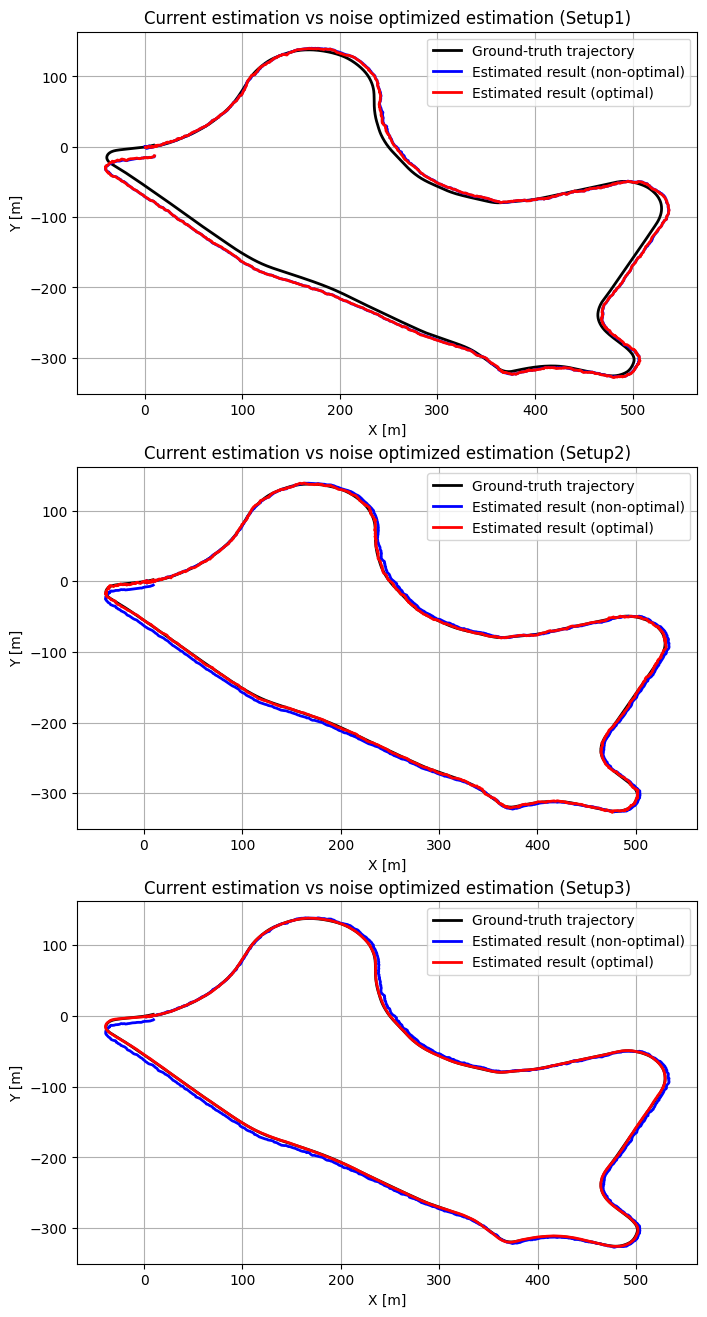

In [7]:
ekf_optimizer.visualize_results()

In [8]:
ekf_optimizer.error_df

Setups        Setup1(IMU+VO)                Setup2(IMU+VO,GPS)                \
Error types              MAE   RMSE     MAX                MAE   RMSE    MAX   
Non-optimized          3.883  5.523  16.490              1.982  2.805  8.911   
Optimized              3.830  5.424  16.244              0.490  0.621  2.304   
∆                     -0.053 -0.099  -0.246             -1.492 -2.184 -6.607   

Setups        Setup3(INS)                
Error types           MAE   RMSE    MAX  
Non-optimized       1.942  2.751  8.198  
Optimized           0.206  0.262  0.930  
∆                  -1.736 -2.489 -7.268

## Conclusion

The noise optimization is successfully applied to the EKF and the resulted noise vectors, including process noise and measurement noise for both VO and GPS, improve the performance of the filter.
In the setup 1 the improvement of the filter can be seen in the maximum error in the entire trajectory by decreasing more than 2 meters after the noise vector optimization. 
In both setup 2 and setup3, the performance improvement can be observed in all metrices.